In [1]:
import sys
sys.path.append('../../scripts')
import utils as util
import stock_indicators as si
import plot as plot
import text_analyzer
import correlation_analyzer as ca

In [2]:
stockutils = util.StockUtils
preprocesser = util.DataPreprocessor

Load the Data.

In [3]:
data = stockutils.load_stock_data('../../data/Stock Data/GOOG.csv')
data.head(5)

,Ticker,Date,Close,High,Low,Open,Volume
0,GOOG,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
1,GOOG,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2,GOOG,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
3,GOOG,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
4,GOOG,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


In [4]:
preprocesser.explore_data(data)

Shape of the data: (3774, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ticker  3774 non-null   object 
 1   Date    3774 non-null   object 
 2   Close   3774 non-null   float64
 3   High    3774 non-null   float64
 4   Low     3774 non-null   float64
 5   Open    3774 non-null   float64
 6   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 206.5+ KB
Info of the data: None


Reorder the columns and keep the ticker symbol.

In [5]:
data = data[['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

In [6]:
stockutils.index_by_date(data)
data.head()

,Ticker,Open,High,Low,Close,Volume
Date,,,,,,
2009-01-02,GOOG,7.633949,7.960977,7.557264,7.948608,144961322
2009-01-05,GOOG,7.940692,8.194003,7.792268,8.115089,196293007
2009-01-06,GOOG,8.237046,8.430492,8.074027,8.263762,257971329
2009-01-07,GOOG,8.121770,8.185839,7.885034,7.965677,180453860
2009-01-08,GOOG,7.873406,8.044340,7.850152,8.044340,144567852


In [7]:
data.describe()

,Open,High,Low,Close,Volume
count,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03
mean,50.753534,51.285163,50.252347,50.779971,6.123096e+07
std,39.389736,39.853299,38.975050,39.417443,5.537396e+07
min,7.133018,7.408840,6.994490,6.994490,1.584340e+05
25%,16.827651,16.984424,16.699388,16.851089,2.574863e+07
50%,37.388390,37.647668,37.038786,37.327805,3.797798e+07
75%,69.062883,70.084894,68.368832,69.191502,8.269781e+07
max,150.831319,151.066223,148.868758,149.684662,5.952147e+08


In [8]:
plotter = plot.Plot

#### Analysis Indicators with TA-Lib

In [9]:
technical_indicators = si.IndicatorCalculator

In [10]:
technical_indicators.calculate_technical_indicators(data)
data.tail(5)

,Ticker,Open,High,Low,Close,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI_14,MACD,MACDSignal,MACD_hist
Date,,,,,,,,,,,,,,
2023-12-22,GOOG,141.164014,142.276397,141.089511,141.750000,18513500,135.009596,133.914786,135.009596,133.914786,64.953309,1.412015,0.572046,0.839969
2023-12-26,GOOG,142.008205,142.966658,141.531472,141.849304,11170100,135.246477,133.999010,135.246477,133.999010,65.115870,1.706565,0.798950,0.907615
2023-12-27,GOOG,141.859236,142.345911,140.092320,140.478683,17288400,135.386520,134.017881,135.386520,134.017881,60.916026,1.808553,1.000870,0.807682
2023-12-28,GOOG,140.885881,141.303025,139.870824,140.319748,12192500,135.628861,134.023641,135.628861,134.023641,60.429303,1.855168,1.171730,0.683438
2023-12-29,GOOG,139.723837,140.473710,138.949139,139.972137,14881000,135.976979,134.056417,135.976979,134.056417,59.313063,1.842820,1.305948,0.536872


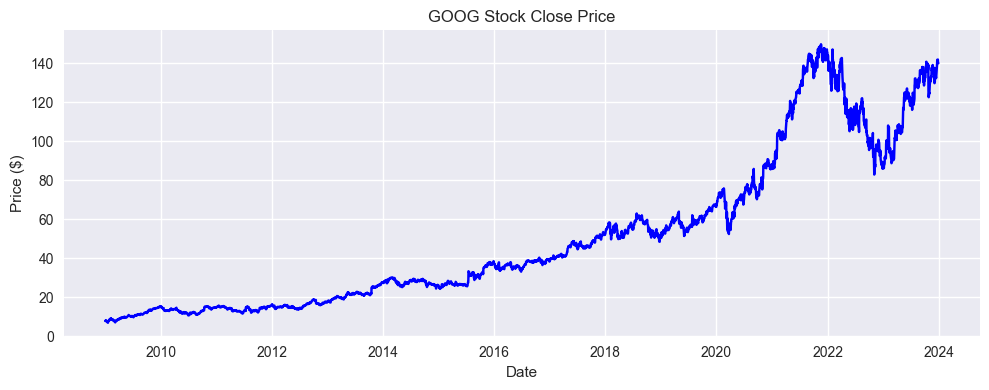

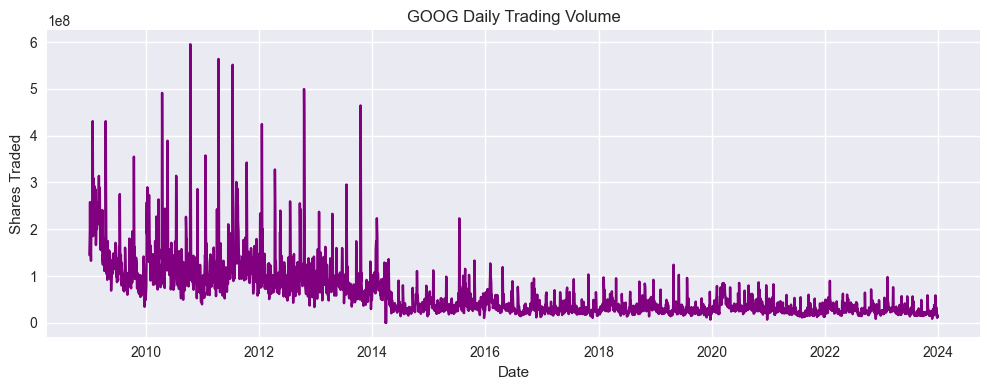

In [11]:
plotter.plot_stock_price(data)

In [12]:
plotter.plot_stock_mva(data)

In [13]:
plotter.plot_ema(data)

In [14]:
plotter.plot_rsi(data)

In [15]:
plotter.plot_macd(data)

### Correlation Analysis

In [16]:
headline_data = util.load_data('../../data/cleaned/cleaned_news_data.csv')

After loading the data, we filter the headlines by stock. And then normalize the dates as we did previously.

In [17]:
headline_data = stockutils.filter_data_by_stock(headline_data, 'GOOG')
preprocesser.convert_date_dtype(headline_data)
headline_data.head(5)

Converted 'date' dtype: datetime64[ns, UTC]


,headline,url,publisher,date,stock
565380,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",https://www.benzinga.com/analyst-ratings/analy...,Shanthi Rexaline,2020-06-10 19:25:13+00:00,GOOG
565381,How Cannabis Company Cannaphyll Is Marketing O...,https://www.benzinga.com/markets/cannabis/20/0...,Jaycee Tenn,2020-06-10 17:18:50+00:00,GOOG
565382,"Twitter, Square Will Mark Juneteenth As Holida...",https://www.benzinga.com/news/20/06/16218441/t...,Shivdeep Dhaliwal,2020-06-10 04:28:00+00:00,GOOG
565383,Price Over Earnings Overview: Alphabet,https://www.benzinga.com/intraday-update/20/06...,Benzinga Insights,2020-06-09 18:39:26+00:00,GOOG
565384,Google Maps To Offer Relevant Local COVID-19 I...,https://www.benzinga.com/news/20/06/16208274/g...,Shivdeep Dhaliwal,2020-06-09 07:51:41+00:00,GOOG


In [18]:
textanaysis = text_analyzer.TextAnalyzer

Here we only keep the relevant columns for the correlation analysis.

In [19]:
headline_with_sentiment = textanaysis.analyze_headline_sentiment(headline_data)
headline_with_sentiment['date'] = headline_with_sentiment ['date'].dt.date

headlines_with_sentiment= headline_with_sentiment[['date', 'headline', 'stock', 'sentiment', 'sentiment_score']].copy()

In [20]:
combined_data = stockutils.merge_sentiment_with_stock(headlines_with_sentiment, data)
combined_data.head()

,headline,stock,sentiment,sentiment_score,Close,Volume
date,,,,,,
2020-06-10,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",GOOG,neutral,0.0000,72.794357,30504000.0
2020-06-10,How Cannabis Company Cannaphyll Is Marketing O...,GOOG,positive,0.1779,72.794357,30504000.0
2020-06-10,"Twitter, Square Will Mark Juneteenth As Holida...",GOOG,positive,0.7096,72.794357,30504000.0
2020-06-09,Price Over Earnings Overview: Alphabet,GOOG,neutral,0.0000,72.313141,28184000.0
2020-06-09,Google Maps To Offer Relevant Local COVID-19 I...,GOOG,neutral,0.0000,72.313141,28184000.0


Update all columns to be in lowercase.

In [21]:
combined_data_lowercase = stockutils.lowercase_columns(combined_data)
combined_data_lowercase.head(5)

,headline,stock,sentiment,sentiment_score,close,volume
date,,,,,,
2020-06-10,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",GOOG,neutral,0.0000,72.794357,30504000.0
2020-06-10,How Cannabis Company Cannaphyll Is Marketing O...,GOOG,positive,0.1779,72.794357,30504000.0
2020-06-10,"Twitter, Square Will Mark Juneteenth As Holida...",GOOG,positive,0.7096,72.794357,30504000.0
2020-06-09,Price Over Earnings Overview: Alphabet,GOOG,neutral,0.0000,72.313141,28184000.0
2020-06-09,Google Maps To Offer Relevant Local COVID-19 I...,GOOG,neutral,0.0000,72.313141,28184000.0


#### Daily Returns

In [22]:
data_with_daily_returns = technical_indicators.calculate_daily_returns(combined_data_lowercase)
data_with_daily_returns.head()

/Users/hazel/Desktop/Self Study/kiam8/kaim-week-1/notebooks/stocks/../../scripts/stock_indicators.py:47: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



,headline,stock,sentiment,sentiment_score,close,volume,daily_returns
date,,,,,,,
2020-06-10,How Cannabis Company Cannaphyll Is Marketing O...,GOOG,positive,0.1779,72.794357,30504000.0,0.000000
2020-06-10,"Twitter, Square Will Mark Juneteenth As Holida...",GOOG,positive,0.7096,72.794357,30504000.0,0.000000
2020-06-09,Price Over Earnings Overview: Alphabet,GOOG,neutral,0.0000,72.313141,28184000.0,-0.006611
2020-06-09,Google Maps To Offer Relevant Local COVID-19 I...,GOOG,neutral,0.0000,72.313141,28184000.0,0.000000
2020-06-08,"Starting This Week, Testing Center Alerts Will...",GOOG,positive,0.5423,71.838890,28084000.0,-0.006558


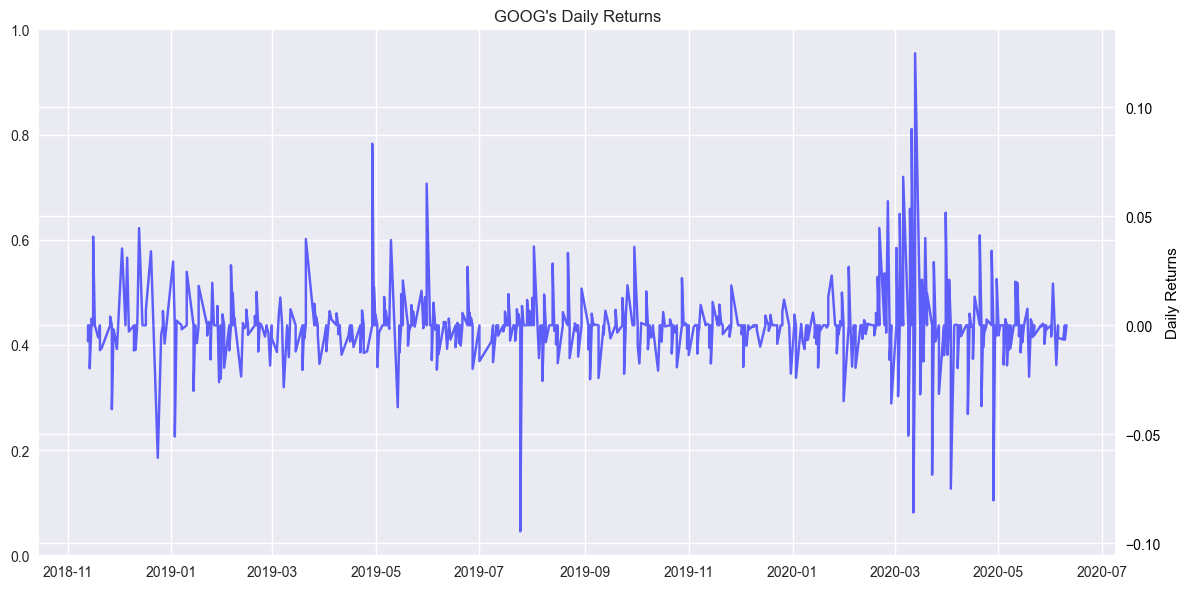

In [23]:
plotter.plot_daily_returns(data_with_daily_returns)

In [24]:
correlation_analysis = ca.CorrelationAnalysis

In [25]:
correlation_analysis.sentiment_correlation_analysis(data_with_daily_returns)

Correlation between sentiment_score and daily_returns is 0.0116
Correlation between sentiment_score and close is -0.0029


(np.float64(0.01155013451004317), np.float64(-0.0029316420545677357))

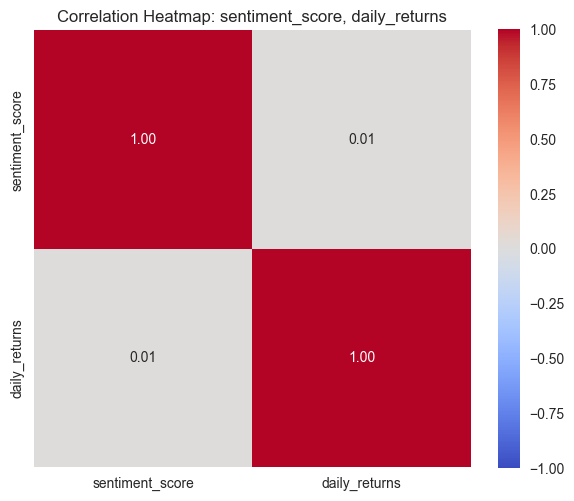

In [26]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'daily_returns' ])

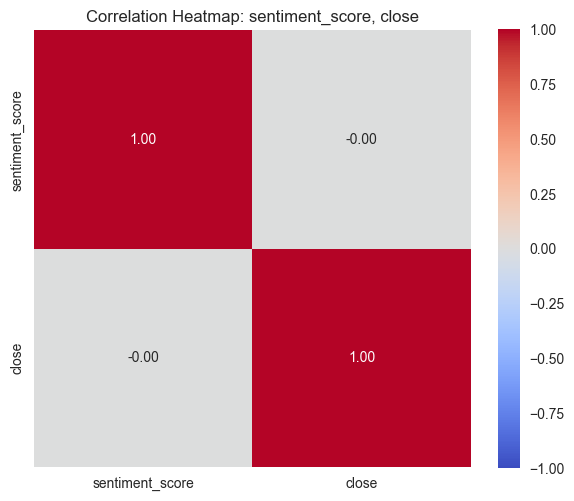

In [27]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'close' ])

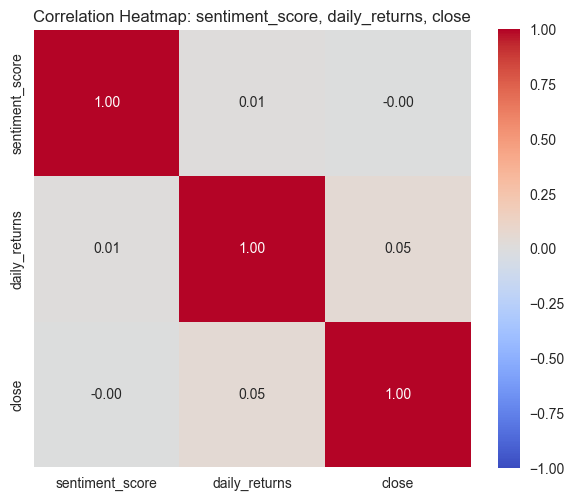

In [28]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'daily_returns', 'close' ])

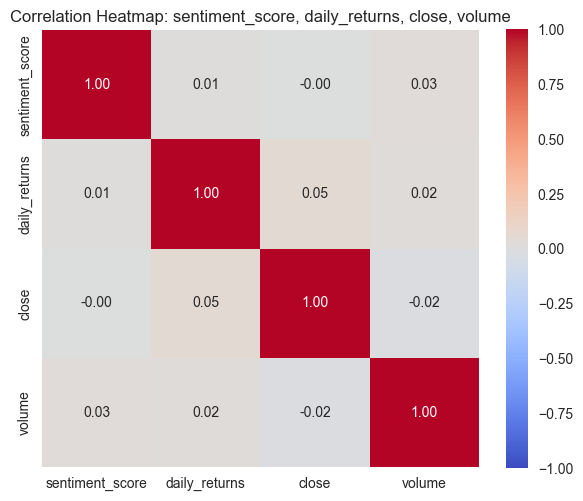

In [29]:
plotter.correlation_heatmap(data_with_daily_returns, ['sentiment_score', 'daily_returns', 'close', 'volume' ])